In [10]:
using LinearAlgebra, StaticArrays, Random, Statistics
using DifferentialEquations
using Rotations
using PythonPlot

include("../report4/safe_mode_gyrostat.jl")
include("../report4/environmental_perturbations.jl")
using .EnvironmentalPerturbations
include("../report4/orbit_gyrostat_environmental.jl")
include("../report4/attitude_control_starling_impl.jl")
include("momentum_dumping.jl")

print_run_summary (generic function with 1 method)

## Spacecraft Parameters

In [11]:
I_body = @SMatrix [
    0.282  0.0    0.0
    0.0    0.188  0.028
    0.0    0.028  0.174
]
e_panel = @SVector [0.0, 1.0, 0.0]

cfg = StarlingConfig(
    I_body     = I_body,
    e_panel    = e_panel,
    alt_km     = 480.0,
    τ_rw_max   = 6e-3,
    rho_rw_max = 50e-3,
    sun_vec_eci = @SVector([1.0, 0.0, 0.0]),
    aero = SpacecraftAeroProperties(
        Cd=2.2, area_m2=0.03, mass_kg=12.0,
        area_normal_body=e_panel,
        center_of_pressure_body_m=SVector(0.02, 0.0, 0.0),
    ),
    srp = SpacecraftSRPProperties(
        Cr=1.3, area_m2=0.03,
        area_normal_body=e_panel,
        center_of_pressure_body_m=SVector(0.02, 0.0, 0.0),
        sun_distance_au=1.0, eclipse=false,
    ),
)

StarlingConfig([0.282 0.0 0.0; 0.0 0.188 0.028; 0.0 0.028 0.174], [3.546099290780142 0.0 -0.0; 0.0 5.449761964419944 -0.8769731896767726; 0.0 -0.8769731896767726 5.888248559258331], [0.0, 1.0, 0.0], 480.0, 6858.1363, 1.698664978058303, 0.0011116286202102177, 0.006, 0.05, [1.0, 0.0, 0.0], EarthEnvironment(3.986004418e14, 6.3781363e6, [0.0, 0.0, 7.2921159e-5], 3.614e-13, 700000.0, 88667.0, 4.56e-6), SpacecraftAeroProperties(2.2, 0.03, 12.0, [0.0, 1.0, 0.0], [0.02, 0.0, 0.0]), SpacecraftSRPProperties(1.3, 0.03, [0.0, 1.0, 0.0], [0.02, 0.0, 0.0], 1.0, false))

## Stress Test

In [12]:
Random.seed!(2026)

T_orbit = orbit_period_seconds_md(cfg)
T_demo  = 4.0 * T_orbit
dt_ctrl = 5.0

qd     = [1.0, 0.0, 0.0, 0.0]
q0     = [1.0, 0.0, 0.0, 0.0]
omega0 = zeros(3)
rho0   = zeros(3)

g_pd       = PDGains(0.005, 0.05)
sigma_gyro = 2e-4
sigma_vec  = 1e-3
V_mekf     = (sigma_gyro^2) * I(3)

stress_estimate = estimate_stress_scale_for_saturation(
    cfg;
    q_ref=SVector{4,Float64}(qd),
    Tfinal=T_demo,
    target_fraction=1.20,
    samples=720,
)
stress_scale = stress_estimate.scale

println("Orbit period = $(round(T_orbit, digits=2)) s")
println("Demo duration = $(round(T_demo / T_orbit, digits=2)) orbits")
println("Mean nominal environmental torque [N*m] = ", stress_estimate.mean_torque_body_Nm)
println("Nominal per-axis momentum growth over demo [N*m*s] = ", stress_estimate.nominal_axis_growth_Nms)
println("Stress-test disturbance scale = ", round(stress_scale; sigdigits=5))

Orbit period = 5652.23 s
Demo duration = 4.0 orbits
Mean nominal environmental torque [N*m] = [-4.693006678471818e-8, 7.936650732378618e-9, 1.5453340643610744e-9]
Nominal per-axis momentum growth over demo [N*m*s] = [0.0010610389143486992, 0.00017943923487852303, 3.4938360208975e-5]
Stress-test disturbance scale = 56.548


## Simulation Runs

In [13]:
common = (;
    Tfinal=T_demo,
    dt=dt_ctrl,
    q0=q0,
    omega0=omega0,
    rho0=rho0,
    qd=qd,
    g=g_pd,
    sigma_gyro=sigma_gyro,
    sigma_vec=sigma_vec,
    V_mekf=V_mekf,
    control_from_truth=false,
    control_gyro_lpf_tau=2.0,
    sigma_bias_walk=1e-5,
    feedforward_external_torque=true,
)

baseline = simulate_momentum_dumping(
    cfg;
    common...,
    rng=MersenneTwister(101),
    disturbance_scale=1.0,
    enable_dumping=false,
)

stressed_no_dump = simulate_momentum_dumping(
    cfg;
    common...,
    rng=MersenneTwister(101),
    disturbance_scale=stress_scale,
    enable_dumping=false,
)

stressed_dump = simulate_momentum_dumping(
    cfg;
    common...,
    rng=MersenneTwister(101),
    disturbance_scale=stress_scale,
    enable_dumping=true,
    dump_gain=2.0e-4,
    dipole_max=0.1,
    dump_deadband=2e-3,
)

(t = 0.0:5.0:22610.0, q_hist = [1.0 0.9999166593334484 … 0.9999904897220402 0.9999917483298453; 0.0 -0.009920998068110124 … 0.004289229288271921 0.003924735131810998; 0.0 0.005322611490288235 … 0.00018934560420763572 0.000427753139713895; 0.0 -0.00631806866791213 … -0.0007662413647870885 -0.0009574725145321702], qh_hist = [0.9950826307272047 0.9981273170447953 … 0.9999994842211788 0.9999988626018274; 0.0910089831269162 0.06064462915208906 … 0.0009751116565051641 0.0005709397752334289; -0.023020641362447806 0.006090361843074902 … 0.000152773288287334 0.0010339114957245402; 0.031590712028881925 -0.005195711364642212 … -0.000239530699976655 -0.0009380031149646731], omega_hist = [0.0 -0.007937231245040326 … -0.00022937653106540237 -4.9526423441082206e-5; 0.0 0.004258116462881048 … -8.028855329294805e-5 0.00012008161394592466; 0.0 -0.005054272612151984 … 0.0006053848038492317 -0.0007512304097615886], beta_hist = [0.0 -6.981846117914873e-6 … -0.002581073804529168 -0.0026001045469227074; 0.0 

In [14]:
summaries = [
    run_summary("Baseline nominal/no dump", baseline, cfg),
    run_summary("Stress test/no dump", stressed_no_dump, cfg),
    run_summary("Stress test/with magnetic dumping", stressed_dump, cfg),
]

for s in summaries
    print_run_summary(s)
end

Baseline nominal/no dump
  disturbance scale: 1.0
  dumping enabled: false
  max |rho_i|: 0.0022382 N*m*s / 0.05
  first saturation: none
  saturated time fraction: 0.0%
  RMS pointing: 0.2417 deg
  max |m_i|: 0.0 A*m^2 / 0.1
  B-field range: 25.1 to 49.89 uT
Stress test/no dump
  disturbance scale: 56.548
  dumping enabled: false
  max |rho_i|: 0.05 N*m*s / 0.05
  first saturation: 18590.0 s
  saturated time fraction: 16.07%
  RMS pointing: 26.4163 deg
  max |m_i|: 0.0 A*m^2 / 0.1
  B-field range: 25.1 to 49.89 uT
Stress test/with magnetic dumping
  disturbance scale: 56.548
  dumping enabled: true
  max |rho_i|: 0.026242 N*m*s / 0.05
  first saturation: none
  saturated time fraction: 0.0%
  RMS pointing: 0.2424 deg
  max |m_i|: 0.1 A*m^2 / 0.1
  B-field range: 25.1 to 49.89 uT


## Results

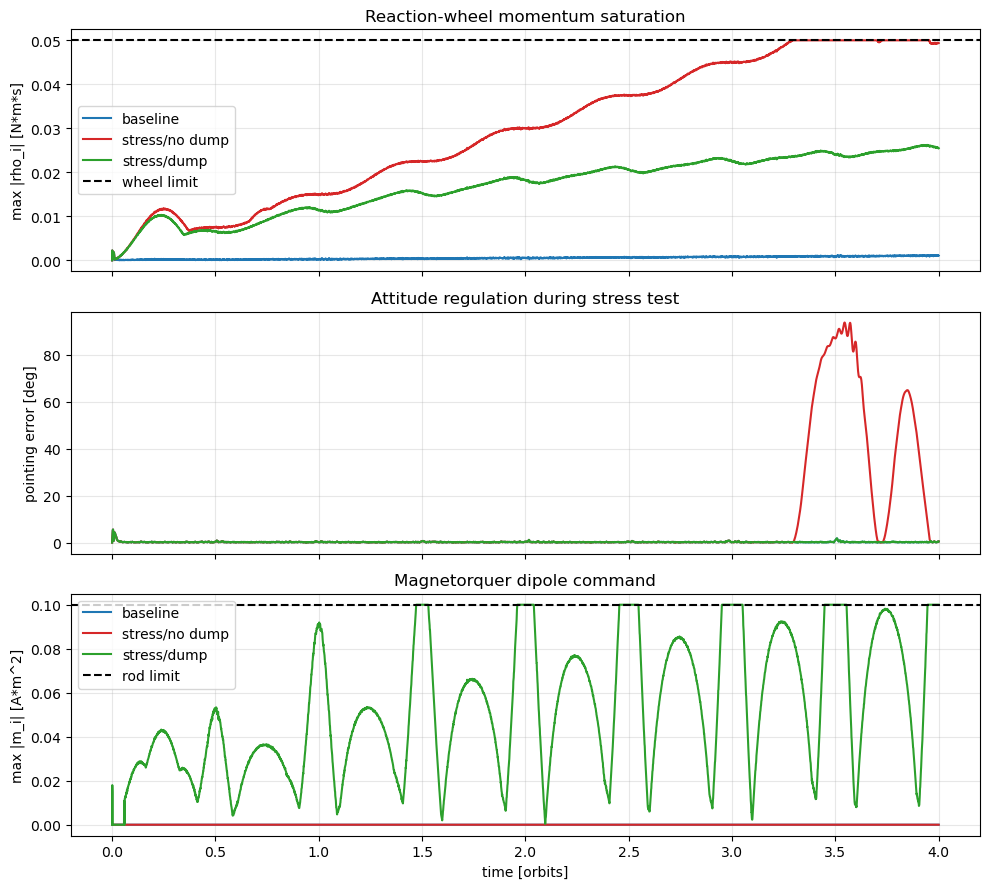

In [15]:
runs = [
    (baseline,        "baseline",      "tab:blue"),
    (stressed_no_dump, "stress/no dump", "tab:red"),
    (stressed_dump,    "stress/dump",    "tab:green"),
]

fig, axs = subplots(3, 1, figsize=(10, 9), sharex=true)

for (sol, label, color) in runs
    torbits        = collect(sol.t) ./ T_orbit
    rho_max        = [maximum(abs.(sol.rho_hist[:, k])) for k in axes(sol.rho_hist, 2)]
    dipole_max_hist = [maximum(abs.(sol.dipole_hist[:, k])) for k in axes(sol.dipole_hist, 2)]
    axs[0].plot(torbits, rho_max,         label=label, color=color)
    axs[1].plot(torbits, sol.ang_hist,    label=label, color=color)
    axs[2].plot(torbits, dipole_max_hist,  label=label, color=color)
end

axs[0].axhline(cfg.rho_rw_max, color="black", linestyle="--", linewidth=1.5, label="wheel limit")
axs[0].set_ylabel("max |rho_i| [N*m*s]")
axs[0].set_title("Reaction-wheel momentum saturation")
axs[0].grid(true, alpha=0.3)
axs[0].legend(loc="best")

axs[1].set_ylabel("pointing error [deg]")
axs[1].set_title("Attitude regulation during stress test")
axs[1].grid(true, alpha=0.3)

axs[2].axhline(0.1, color="black", linestyle="--", linewidth=1.5, label="rod limit")
axs[2].set_ylabel("max |m_i| [A*m^2]")
axs[2].set_xlabel("time [orbits]")
axs[2].set_title("Magnetorquer dipole command")
axs[2].grid(true, alpha=0.3)
axs[2].legend(loc="best")

fig.tight_layout()
mkpath("figs")
savefig("figs/momentum_dumping_stress_test.png", bbox_inches="tight")
display(fig)

In [16]:
no_dump_summary = summaries[2]
dump_summary    = summaries[3]

println("Validation checks:")
println("  stressed no-dump reaches saturation: ", no_dump_summary.first_saturation_s !== nothing)
println("  dumping reduces max wheel momentum:  ", dump_summary.max_abs_rho_Nms < no_dump_summary.max_abs_rho_Nms)
println("  dipole command respects rod limit:   ", dump_summary.max_dipole_Am2 <= dump_summary.dipole_limit_Am2 + 1e-12)
println("  dipole B-field remains LEO-like:     ", 10.0 <= dump_summary.mean_B_uT <= 80.0)

Validation checks:
  stressed no-dump reaches saturation: true
  dumping reduces max wheel momentum:  true
  dipole command respects rod limit:   true
  dipole B-field remains LEO-like:     true


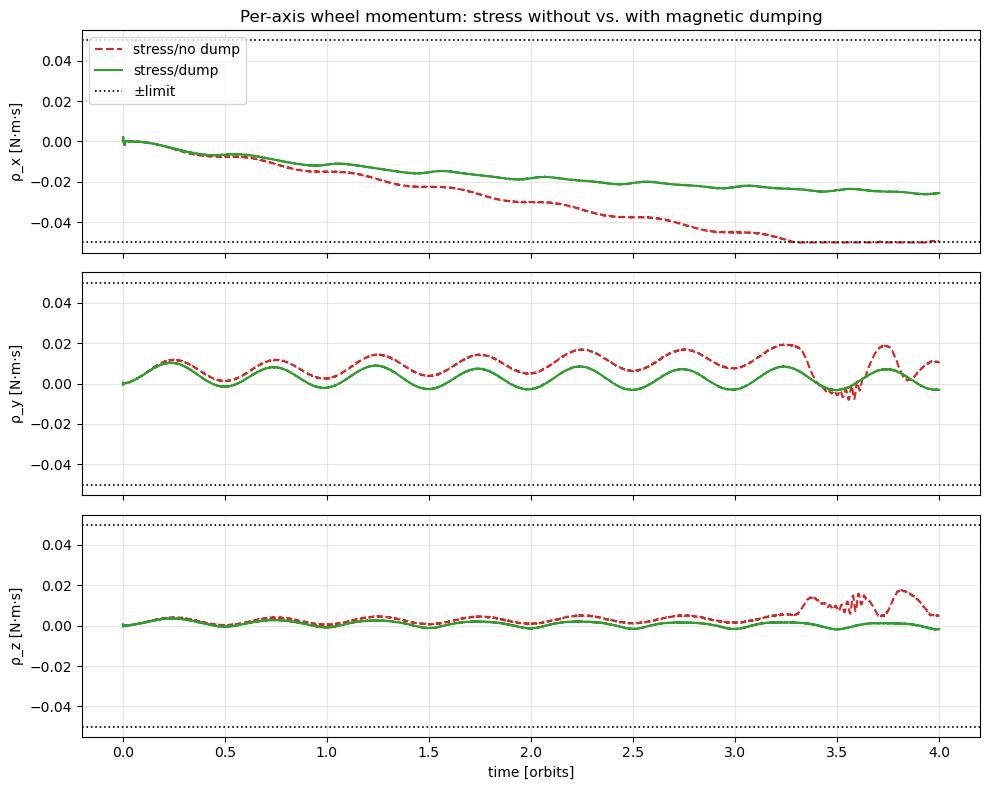

In [17]:
axis_names = ["x", "y", "z"]

fig2, axs2 = subplots(3, 1, figsize=(10, 8), sharex=true)

for (sol, label, color, ls) in [
    (stressed_no_dump, "stress/no dump", "tab:red",   "--"),
    (stressed_dump,    "stress/dump",    "tab:green", "-"),
]
    torbits = collect(sol.t) ./ T_orbit
    for j in 0:2
        axs2[j].plot(torbits, sol.rho_hist[j+1, :], label=label, color=color, linestyle=ls)
    end
end

for j in 0:2
    axs2[j].axhline( cfg.rho_rw_max, color="black", linestyle=":", linewidth=1.2,
                     label=(j == 0 ? "\u00b1limit" : "_nolegend_"))
    axs2[j].axhline(-cfg.rho_rw_max, color="black", linestyle=":", linewidth=1.2, label="_nolegend_")
    axs2[j].set_ylabel("ρ_$(axis_names[j+1]) [N⋅m⋅s]")
    axs2[j].grid(true, alpha=0.3)
end

axs2[0].set_title("Per-axis wheel momentum: stress without vs. with magnetic dumping")
axs2[0].legend(loc="upper left")
axs2[2].set_xlabel("time [orbits]")

fig2.tight_layout()
savefig("figs/momentum_dumping_per_axis.png", bbox_inches="tight")
display(fig2)

## MeshCat Visualization

In [18]:
using MeshCat
using GeometryBasics
using CoordinateTransformations
using Colors

include("momentum_dumping_meshcat.jl")

mesh_result = run_three_meshcat_demos(
    cfg;
    T_demo=T_demo,
    dt_ctrl=dt_ctrl,
    qd=Vector{Float64}(qd),
    stress_scale=stress_scale,
    g_pd=g_pd,
    rng=MersenneTwister(101),
    subsample=25,
    frame_pause=0.015,
    playback_slowdown=3.0,
    pause_between_scenarios=1.5,
)

[ Info: Listening on: 127.0.0.1:8704, thread id: 1
┌ Info: MeshCat server started. You can open the visualizer by visiting the following URL in your browser:
└ http://127.0.0.1:8704
[ Info: MeshCat scenario 1/3: disturbance only (no wheel torque)
[ Info: MeshCat scenario 2/3: reaction wheels (saturate under stress, no magnetic dumping)
[ Info: MeshCat scenario 3/3: wheels + magnetorquers (momentum dumping, attitude recovery)


(vis = MeshCat Visualizer with path /meshcat at http://127.0.0.1:8704, sol_disturb = (t = 0.0:5.0:22610.0, q_hist = [1.0 0.9999999982412683 … -0.1263221073706295 -0.3689666237681119; 0.0 -2.256955788803587e-10 … 0.2431743258392943 0.6414201165780462; 0.0 5.9231061384817045e-5 … 0.35363148116034127 0.23987501641107473; 0.0 3.0240377699266277e-6 … 0.8943454298951782 0.6284137499259169], qh_hist = [0.9950826307272047 0.9977595233165177 … -0.1261149143817468 -0.369559294023985; 0.0910089831269162 0.06689558074453156 … 0.24253173447554235 0.6405972735425172; -0.023020641362447806 0.0005189632783584675 … 0.3524730902829643 0.23858076805856132; 0.031590712028881925 0.0008034831442339353 … 0.8950062048774563 0.6293967575726571], omega_hist = [0.0 -3.6111292597127e-10 … 0.00014780856784875655 0.0006309652032780481; 0.0 4.738484914227164e-5 … -0.1350269057783917 -0.1353904406122056; 0.0 2.4192302094220188e-6 … 0.17659900937792886 0.1765984841250614], beta_hist = [0.0 -6.981846117914871e-8 … -2.5